# Install packages

In [0]:
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.7/796.7 kB 12.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install spotipy

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.5/547.5 kB 6.9 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Import packages

In [0]:
# basic packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from collections import Counter
import os

# NLP packages

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# spotify packages

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

In [0]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/spark-6b1f9840-9421-41d2-984d-ff/nltk_data...


True

In [0]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-6b1f9840-9421-41d2-984d-ff/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [0]:
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/spark-6b1f9840-9421-41d2-984d-ff/nltk_data...


True

# Spotity clients

In [0]:
# create a proyect and retrieval the credentials

# https://developer.spotify.com/documentation/web-api

client_id = "42e39ebda6fc49d48d9a3b3548317b88"
client_secret = "2b200bcd78284aa4b6e2c8a041e536e9" 

In [0]:
# create a Spotify client

client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

# Search artist

In [0]:
# search artist

artist_name = 'The killers'
artist_results = sp.search(q=artist_name, type='artist', limit=5)

In [0]:
# show posible results

for artist_name in artist_results['artists']['items']:
    print(artist_name['name'])

The Killers
Taylor Swift
Queen
Brandon Flowers
Bob Marley & The Wailers


In [0]:
# select the first coincidence

artist_metadata = artist_results['artists']['items'][0]

In [0]:
artist_metadata['name']

'The Killers'

In [0]:
# extract metadata

followers = artist_metadata['followers']['total']
genero = ",".join(artist_metadata['genres'])
popularidad = artist_metadata['popularity']

# Get albums

In [0]:
# get albums

artist_id_s = artist_results['artists']['items'][0]['id']
list_artist_albums = sp.artist_albums(artist_id_s, album_type='album')

In [0]:
def parse_release_date(x):
    if len(str(x)) == 4:
        return pd.to_datetime(f"{x}-01-01")
    else:
        return pd.to_datetime(x)

# Compound score

- -1 → sentimiento extremadamente negativo
- 0 → sentimiento neutral
- +1 → sentimiento extremadamente positivo

**Interpretación**

- ≥ 0.05 Positivo
- ≤ -0.05 Negativo
- Entre -0.05 y 0.05 Neutral

In [0]:
def get_sentiment_label(x):
    if x >= 0.05:
        return 'Positivo'
    elif x <= -0.05:
        return 'Negativo'
    else:
        return 'Neutral' 

In [0]:
# build album dataframe with extra attributes

sid = SentimentIntensityAnalyzer()

rows = []

for album in list_artist_albums['items']:

    sentiment_scores = sid.polarity_scores(album['name'])

    rows.append({
        'album_id': album['id'],
        'album_name': album['name'],
        'album_type': album['type'],
        'total_tracks': album['total_tracks'],
        'release_date': album['release_date'],
        'num_markets': len(album.get('available_markets', [])),
        'album_cover': album['images'][0]['url'] if album.get('images') else None,
        'sentiment_neg': sentiment_scores['neg'],
        'sentiment_neu': sentiment_scores['neu'],
        'sentiment_pos': sentiment_scores['pos'],
        'compound_score': sentiment_scores['compound'],
    })

df_all_albumns = pd.DataFrame(rows)

df_all_albumns['release_date'] = df_all_albumns['release_date'].apply(parse_release_date)
df_all_albumns['popularity'] = popularidad
df_all_albumns['followers'] = followers
df_all_albumns['genres'] = genero
df_all_albumns['artist_name'] = artist_metadata['name']
df_all_albumns['artist_id'] = artist_id_s

In [0]:
df_all_albumns['album_year'] = df_all_albumns.release_date.dt.year

In [0]:
df_all_albumns

,album_id,album_name,album_type,total_tracks,release_date,num_markets,album_cover,sentiment_neg,sentiment_neu,sentiment_pos,compound_score,popularity,followers,genres,artist_name,artist_id,album_year
0,01Go8OwdhESlkxPwrx6515,Pressure Machine (Deluxe),album,18,2022-03-25,183,https://i.scdn.co/image/ab67616d0000b273fbb8ee...,0.524,0.476,0.000,-0.2960,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2022
1,1qMFjBarjO2xD15BwXZguD,Pressure Machine,album,11,2021-08-13,184,https://i.scdn.co/image/ab67616d0000b273821b45...,0.688,0.312,0.000,-0.2960,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2021
2,7j8a2kSxAtenkXPim6mwUB,Pressure Machine (Abridged),album,11,2021-08-12,184,https://i.scdn.co/image/ab67616d0000b27330cfd1...,0.524,0.476,0.000,-0.2960,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2021
3,7CicJk8ELO3w5os2fr2LBQ,Imploding The Mirage (Deluxe),album,13,2021-01-29,184,https://i.scdn.co/image/ab67616d0000b273f26061...,0.000,1.000,0.000,0.0000,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2021
4,1uROBP2G4MP0O4w1v5Cpbg,Imploding The Mirage,album,10,2020-08-21,184,https://i.scdn.co/image/ab67616d0000b273f08d82...,0.000,1.000,0.000,0.0000,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2020
5,5TMnKX3SaYXgYsmFuH8mxB,Wonderful Wonderful (Deluxe),album,13,2017-09-22,184,https://i.scdn.co/image/ab67616d0000b273e7664a...,0.000,0.119,0.881,0.8126,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2017
6,30huok00bCQ0TxIJDtz09w,Don't Waste Your Wishes,album,11,2016-01-01,184,https://i.scdn.co/image/ab67616d0000b273ddb58f...,0.250,0.346,0.404,0.2235,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2016
7,6P6DYLagXUhE5Qq2l79Ef1,Battle Born (Deluxe Edition),album,15,2012-09-17,183,https://i.scdn.co/image/ab67616d0000b273fb59f2...,0.464,0.536,0.000,-0.3818,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2012
8,1TYHZLZv5mLBkajWsV7cQq,Live From The Royal Albert Hall,album,17,2009-11-03,184,https://i.scdn.co/image/ab67616d0000b2739b752f...,0.000,1.000,0.000,0.0000,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2009
9,0Ug5scDXUIgGN8yanDBLQw,Day & Age (Bonus Tracks),album,12,2008-11-18,184,https://i.scdn.co/image/ab67616d0000b273a43cd4...,0.000,1.000,0.000,0.0000,79,8507359,alternative rock,The Killers,0C0XlULifJtAgn6ZNCW2eu,2008


In [0]:
df_all_albumns.compound_score.mean()

np.float64(-0.019474999999999992)

In [0]:
df_year = (
    df_all_albumns
    .groupby('album_year')
    .agg(
        compound_score=('compound_score', 'mean'),
        total_tracks=('total_tracks', 'sum')
    )
    .reset_index()
)
df_year['album_year'] = df_year['album_year'].astype(str)

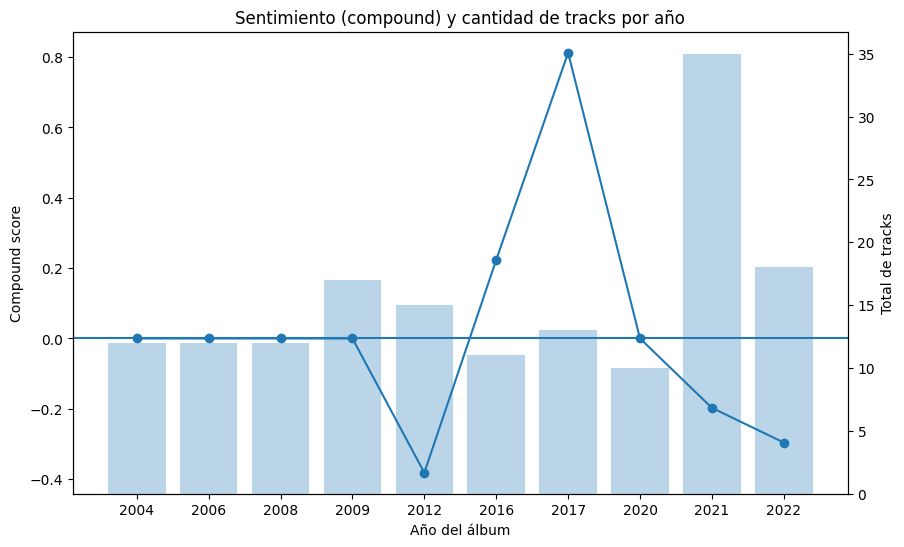

In [0]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    df_year['album_year'],
    df_year['compound_score'],
    marker='o'
)
ax1.set_xlabel('Año del álbum')
ax1.set_ylabel('Compound score')
ax1.axhline(0)

ax2 = ax1.twinx()
ax2.bar(
    df_year['album_year'],
    df_year['total_tracks'],
    alpha=0.3
)
ax2.set_ylabel('Total de tracks')

plt.title('Sentimiento (compound) y cantidad de tracks por año')
plt.show()

# Album-level extra analysis

In [0]:
# tracks per album

df_all_albumns.sort_values('total_tracks', ascending=False)[['album_name','album_year','total_tracks']].head(10)

,album_name,album_year,total_tracks
0,Pressure Machine (Deluxe),2022,18
8,Live From The Royal Albert Hall,2009,17
7,Battle Born (Deluxe Edition),2012,15
3,Imploding The Mirage (Deluxe),2021,13
5,Wonderful Wonderful (Deluxe),2017,13
9,Day & Age (Bonus Tracks),2008,12
10,Sam's Town,2006,12
11,Hot Fuss,2004,12
1,Pressure Machine,2021,11
2,Pressure Machine (Abridged),2021,11


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2004'),
  Text(1, 0, '2006'),
  Text(2, 0, '2008'),
  Text(3, 0, '2009'),
  Text(4, 0, '2012'),
  Text(5, 0, '2016'),
  Text(6, 0, '2017'),
  Text(7, 0, '2020'),
  Text(8, 0, '2021'),
  Text(9, 0, '2022')])

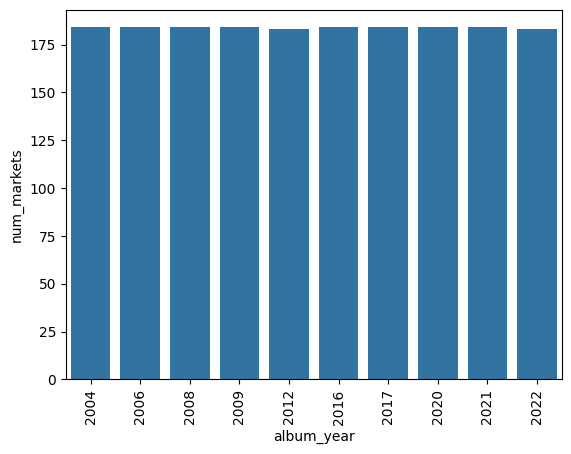

In [0]:
# market reach per album

sns.barplot(data=df_all_albumns.sort_values('album_year'), x='album_year', y='num_markets')
plt.xticks(rotation=90)

# Song analysis

In [0]:
nombre_artista = 'The killers'
resultados_artista = sp.search(q=nombre_artista, type='artist', limit=1)

In [0]:
# extract track info: title, album, and track id for later enrichment

if resultados_artista and 'artists' in resultados_artista:
    artistas = resultados_artista['artists']['items']
    if artistas:
        id_artista = artistas[0]['id']

        albums_artista = sp.artist_albums(id_artista, album_type='album')

        datos_canciones = []

        for album in albums_artista['items']:
            nombre_album = album['name']
            canciones_album = sp.album_tracks(album['id'])

            for cancion in canciones_album['items']:
                titulo_cancion = cancion['name']
                puntuaciones_sentimiento = sid.polarity_scores(titulo_cancion)
                label_sentiment = get_sentiment_label(puntuaciones_sentimiento['compound'])

                datos_canciones.append({
                    'track_id': cancion['id'],
                    'title_name': titulo_cancion,
                    'title_length': len(titulo_cancion),
                    'title_word_count': len(titulo_cancion.split()),
                    'compound_score': puntuaciones_sentimiento['compound'],
                    'sentiment': label_sentiment,
                    'album': nombre_album
                })

        df_song = pd.DataFrame(datos_canciones)

# Enrich songs with popularity, explicit and duration

`sp.album_tracks` no devuelve estos campos. Llamamos a `sp.tracks` por lotes de 50.

In [0]:
# batched enrichment

track_ids = df_song['track_id'].dropna().unique().tolist()

extra = []

for i in range(0, len(track_ids), 50):
    batch = track_ids[i:i+50]
    res = sp.tracks(batch)
    for t in res['tracks']:
        if t is None:
            continue
        extra.append({
            'track_id': t['id'],
            'popularity': t['popularity'],
            'explicit': t['explicit'],
            'duration_min': t['duration_ms'] / 60000,
        })

df_extra = pd.DataFrame(extra)
df_song = df_song.merge(df_extra, on='track_id', how='left')
df_song.head()

,track_id,title_name,title_length,title_word_count,compound_score,sentiment,album,popularity,explicit,duration_min
0,4DfK3WIqrFbj4j0V70eMGf,West Hills,10,2,0.0000,Neutral,Pressure Machine (Deluxe),37,False,5.700217
1,6SJ9bSz0xZUeYEi3kqdGyX,Quiet Town,10,2,0.0000,Neutral,Pressure Machine (Deluxe),36,False,4.756000
2,2dgItzKs3i7oNz59BiPll4,Terrible Thing,14,2,-0.4767,Negativo,Pressure Machine (Deluxe),33,False,3.874000
3,6cCGNT0aKZtrsudYMAyQoM,Cody,4,1,0.0000,Neutral,Pressure Machine (Deluxe),33,False,3.847767
4,65Lnl3mb6lHHzlnDxpvwcC,Sleepwalker,11,1,0.0000,Neutral,Pressure Machine (Deluxe),33,False,4.465767


In [0]:
df_song

,track_id,title_name,title_length,title_word_count,compound_score,sentiment,album,popularity,explicit,duration_min
0,4DfK3WIqrFbj4j0V70eMGf,West Hills,10,2,0.0000,Neutral,Pressure Machine (Deluxe),37,False,5.700217
1,6SJ9bSz0xZUeYEi3kqdGyX,Quiet Town,10,2,0.0000,Neutral,Pressure Machine (Deluxe),36,False,4.756000
2,2dgItzKs3i7oNz59BiPll4,Terrible Thing,14,2,-0.4767,Negativo,Pressure Machine (Deluxe),33,False,3.874000
3,6cCGNT0aKZtrsudYMAyQoM,Cody,4,1,0.0000,Neutral,Pressure Machine (Deluxe),33,False,3.847767
4,65Lnl3mb6lHHzlnDxpvwcC,Sleepwalker,11,1,0.0000,Neutral,Pressure Machine (Deluxe),33,False,4.465767
...,...,...,...,...,...,...,...,...,...,...
150,2N7TN76tLuTcdn9UlS8ADT,Change Your Mind,16,3,0.0000,Neutral,Hot Fuss,61,False,3.200000
151,7gS9H5JtkJZgUZBq5mWY4P,Believe Me Natalie,18,3,0.0000,Neutral,Hot Fuss,51,False,5.083550
152,4gAhDQjQT9rReQk5NoaiED,Midnight Show,13,2,0.0000,Neutral,Hot Fuss,52,False,4.054883
153,3nFhiJReGYBDoqArWW3p5e,Everything Will Be Alright,26,4,0.2500,Positivo,Hot Fuss,49,False,5.748433


In [0]:
# sort by compound score

df_song.sort_values('compound_score', ascending=False)

,track_id,title_name,title_length,title_word_count,compound_score,sentiment,album,popularity,explicit,duration_min
63,34Z7ksxNZ5UttoqD0ZLa6P,Wonderful Wonderful,19,2,0.8126,Positivo,Wonderful Wonderful (Deluxe),33,False,5.175100
69,7aPhHopd7f2qVb3rUKq1ZF,Some Kind Of Love,17,4,0.6369,Positivo,Wonderful Wonderful (Deluxe),35,False,4.634883
76,4PYTPrQZz2kt6KU1vNH9Ri,A Great Big Sled,16,4,0.6249,Positivo,Don't Waste Your Wishes,27,False,4.376433
109,4tmcqEopxvOrzquyoYhRAz,Smile Like You Mean It - Live From The Royal A...,63,14,0.6124,Positivo,Live From The Royal Albert Hall,36,False,4.294433
145,3KANrKOFYyAxfjQJHkgBdb,Smile Like You Mean It,22,5,0.6124,Positivo,Hot Fuss,73,False,3.901767
...,...,...,...,...,...,...,...,...,...,...
119,4gsOR9hEmZqJF8BSLKuHUA,Losing Touch,12,2,-0.3818,Negativo,Day & Age (Bonus Tracks),52,False,4.227550
2,2dgItzKs3i7oNz59BiPll4,Terrible Thing,14,2,-0.4767,Negativo,Pressure Machine (Deluxe),33,False,3.874000
31,6bEsg3rzal9jDkut98dhiL,Terrible Thing - Abridged,25,4,-0.4767,Negativo,Pressure Machine (Abridged),30,False,3.948667
20,7kt048gjB3FBX8PjtZoNKj,Terrible Thing,14,2,-0.4767,Negativo,Pressure Machine,33,False,3.874000


# Top songs by popularity

In [0]:
df_song.sort_values('popularity', ascending=False).head(10)

,track_id,title_name,title_length,title_word_count,compound_score,sentiment,album,popularity,explicit,duration_min
144,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,14,2,0.0000,Neutral,Hot Fuss,94,False,3.716217
146,6PwjJ58I4t7Mae9xfZ9l9v,Somebody Told Me,16,3,0.0000,Neutral,Hot Fuss,86,False,3.286667
133,70wYA8oYHoMzhRRkARoMhU,When You Were Young,19,4,0.0000,Neutral,Sam's Town,81,False,3.673767
120,1sTsuZTdANkiFd7T34H3nb,Human,5,1,0.0000,Neutral,Day & Age (Bonus Tracks),79,False,4.089550
147,5vollujufHY0jMZxx77VWr,All These Things That I've Done,31,6,0.0000,Neutral,Hot Fuss,79,False,5.031100
136,7cX4PJz1old9fyFI8RlfgW,Read My Mind,12,3,0.0000,Neutral,Sam's Town,74,False,4.114000
145,3KANrKOFYyAxfjQJHkgBdb,Smile Like You Mean It,22,5,0.6124,Positivo,Hot Fuss,73,False,3.901767
121,1A8SxnqRK3qabmuN2qxIpa,Spaceman,8,1,0.0000,Neutral,Day & Age (Bonus Tracks),67,False,4.742433
143,60eVCXFCuw1WYswBuNZc4H,Jenny Was A Friend Of Mine,26,6,0.4939,Positivo,Hot Fuss,67,False,4.065550
135,6suRRwX61xSMfU7wJuCVdy,For Reasons Unknown,19,3,0.0000,Neutral,Sam's Town,66,False,3.537767


In [0]:
df_song.sort_values('popularity', ascending=True).head(10)

,track_id,title_name,title_length,title_word_count,compound_score,sentiment,album,popularity,explicit,duration_min
86,0GOpOiyJSPkn6PkxcxDiiI,I'll Be Home For Christmas,26,5,0.0000,Neutral,Don't Waste Your Wishes,16,False,5.969333
85,12vHAN6r7R7OqRswn4O9hL,Dirt Sledding,13,2,-0.3400,Negativo,Don't Waste Your Wishes,21,False,4.486000
84,3QC0fp3rEIymdgiP1OT4mD,Joel The Lump Of Coal,21,5,0.0000,Neutral,Don't Waste Your Wishes,22,False,3.985333
78,3sP7Degi5k17ymz7yLvC2w,"Joseph, Better You Than Me",26,5,0.4404,Positivo,Don't Waste Your Wishes,24,False,4.863767
81,35HSY6uzdUJd5ur9JtYkTA,The Cowboys' Christmas Ball,27,4,0.0000,Neutral,Don't Waste Your Wishes,24,False,3.528883
83,66JPcGJiZFA1iDR94kGC0k,Christmas In L.A.,17,3,0.0000,Neutral,Don't Waste Your Wishes,25,False,4.399767
82,1P3322ab2h0Cf67HcjNk4s,I Feel It In My Bones,21,6,0.0000,Neutral,Don't Waste Your Wishes,26,False,3.635100
17,6TRe0Yfzd2c894P2BxgJux,West Hills III,14,3,0.0000,Neutral,Pressure Machine (Deluxe),26,False,3.840217
37,7sNHB6Gy8qOEtytwidYrSy,Desperate Things - Abridged,27,4,-0.3182,Negativo,Pressure Machine (Abridged),27,False,5.350667
76,4PYTPrQZz2kt6KU1vNH9Ri,A Great Big Sled,16,4,0.6249,Positivo,Don't Waste Your Wishes,27,False,4.376433


# Sentiment label distribution

In [0]:
df_song['sentiment'].value_counts()

sentiment
Neutral     114
Positivo     23
Negativo     18
Name: count, dtype: int64

<Axes: xlabel='sentiment', ylabel='count'>

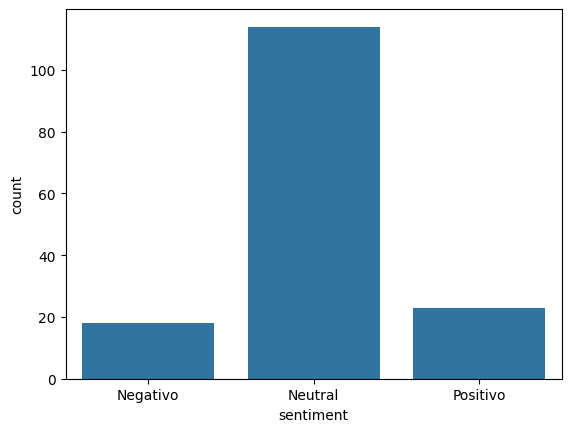

In [0]:
sns.countplot(data=df_song, x='sentiment', order=['Negativo','Neutral','Positivo'])

Text(0.5, 0, 'número de canciones')

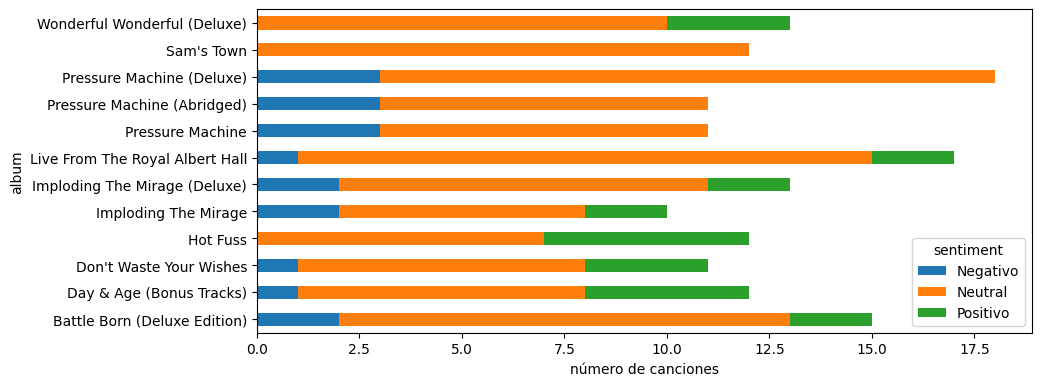

In [0]:
# stacked distribution per album

df_stack = df_song.groupby(['album','sentiment']).size().unstack(fill_value=0)
df_stack = df_stack[[c for c in ['Negativo','Neutral','Positivo'] if c in df_stack.columns]]

df_stack.plot(kind='barh', stacked=True, figsize=(10, max(4, 0.35*len(df_stack))))
plt.xlabel('número de canciones')

# Sentiment vs popularity

¿Las canciones con título positivo son más populares?

In [0]:
df_song.groupby('sentiment').agg({
    'popularity': ['mean','median','count'],
    'compound_score': 'mean',
    'duration_min': 'mean',
})

popularity              compound_score duration_min
                mean median count           mean         mean
sentiment                                                    
Negativo   36.055556   33.0    18      -0.372444     4.587836
Neutral    41.017544   37.0   114       0.000226     4.172589
Positivo   40.652174   36.0    23       0.436339     4.394679

<Axes: xlabel='sentiment', ylabel='popularity'>

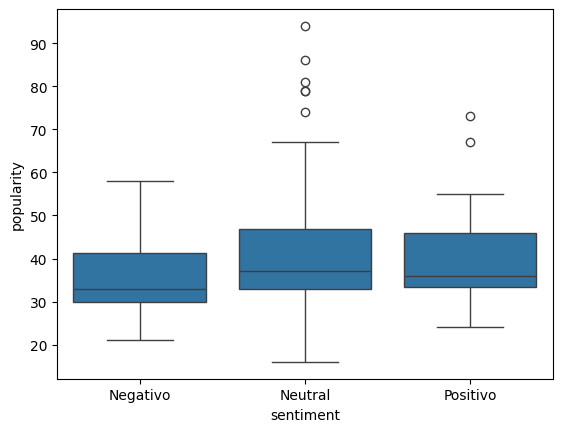

In [0]:
sns.boxplot(data=df_song, x='sentiment', y='popularity', order=['Negativo','Neutral','Positivo'])

<Axes: xlabel='compound_score', ylabel='popularity'>

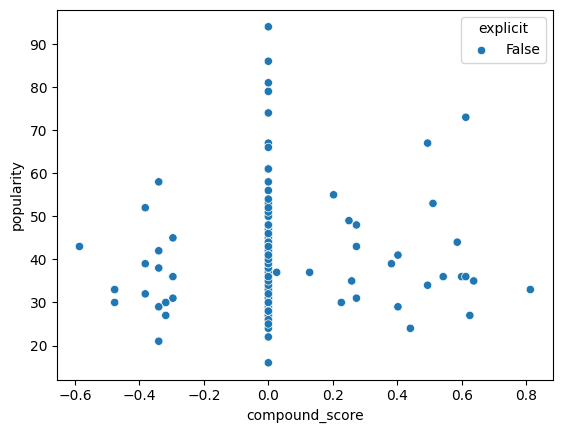

In [0]:
sns.scatterplot(data=df_song, x='compound_score', y='popularity', hue='explicit')

# Title length analysis

<Axes: xlabel='title_word_count', ylabel='popularity'>

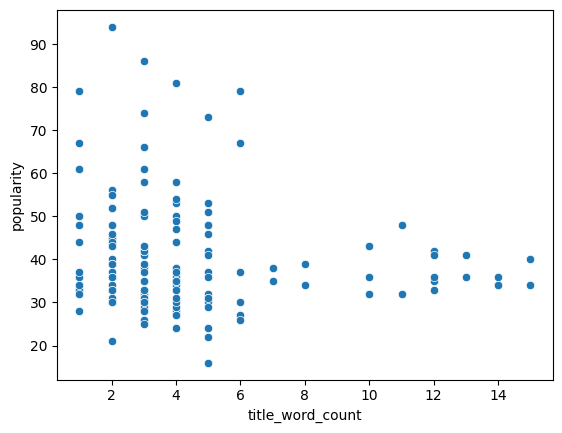

In [0]:
sns.scatterplot(data=df_song, x='title_word_count', y='popularity')

<Axes: xlabel='title_length', ylabel='compound_score'>

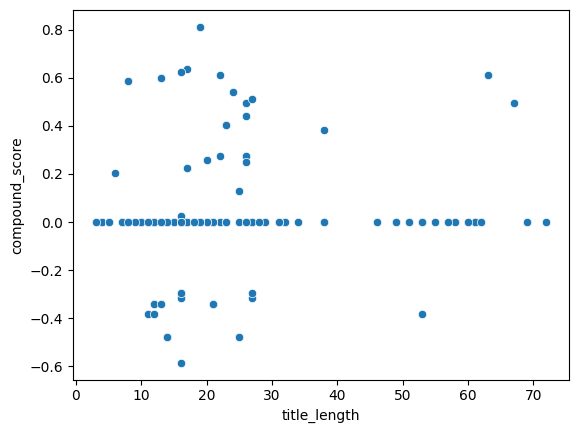

In [0]:
sns.scatterplot(data=df_song, x='title_length', y='compound_score')

# Album-level summary using enriched data

In [0]:
df_album_summary = df_song.groupby('album').agg(
    n_tracks=('track_id','nunique'),
    avg_popularity=('popularity','mean'),
    avg_duration=('duration_min','mean'),
    avg_compound=('compound_score','mean'),
    pct_explicit=('explicit', lambda x: x.mean()*100),
).reset_index().rename(columns={'album':'album_name'})

df_album_summary = df_album_summary.merge(
    df_all_albumns[['album_name','release_date','album_year']],
    on='album_name',
    how='left'
).sort_values('album_year')

df_album_summary

,album_name,n_tracks,avg_popularity,avg_duration,avg_compound,pct_explicit,release_date,album_year
3,Hot Fuss,12,64.500000,4.156883,0.172433,0.0,2004-01-01,2004
10,Sam's Town,12,56.583333,3.686475,0.000000,0.0,2006-09-27,2006
1,Day & Age (Bonus Tracks),12,51.000000,4.071550,0.116783,0.0,2008-11-18,2008
6,Live From The Royal Albert Hall,17,37.235294,4.615053,0.042618,0.0,2009-11-03,2009
0,Battle Born (Deluxe Edition),15,38.466667,4.365299,-0.014300,0.0,2012-09-17,2012
2,Don't Waste Your Wishes,11,25.090909,4.488195,0.089427,0.0,2016-01-01,2016
11,Wonderful Wonderful (Deluxe),13,34.307692,4.218763,0.128908,0.0,2017-09-22,2017
4,Imploding The Mirage,10,48.200000,4.206905,-0.000490,0.0,2020-08-21,2020
5,Imploding The Mirage (Deluxe),13,32.076923,3.995633,-0.000377,0.0,2021-01-29,2021
7,Pressure Machine,11,38.000000,4.669855,-0.099173,0.0,2021-08-13,2021


<Axes: xlabel='album_year', ylabel='avg_popularity'>

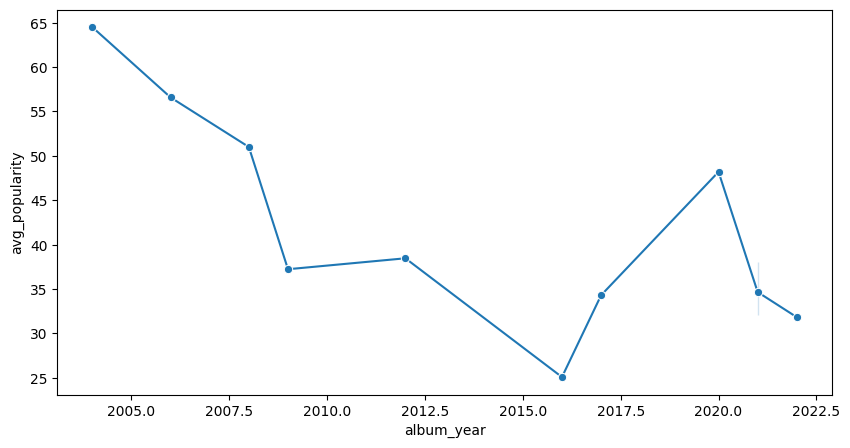

In [0]:
# popularity per album across time

plt.figure(figsize=(10,5))
sns.lineplot(data=df_album_summary, x='album_year', y='avg_popularity', marker='o')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2004'),
  Text(1, 0, '2006'),
  Text(2, 0, '2008'),
  Text(3, 0, '2009'),
  Text(4, 0, '2012'),
  Text(5, 0, '2016'),
  Text(6, 0, '2017'),
  Text(7, 0, '2020'),
  Text(8, 0, '2021'),
  Text(9, 0, '2022')])

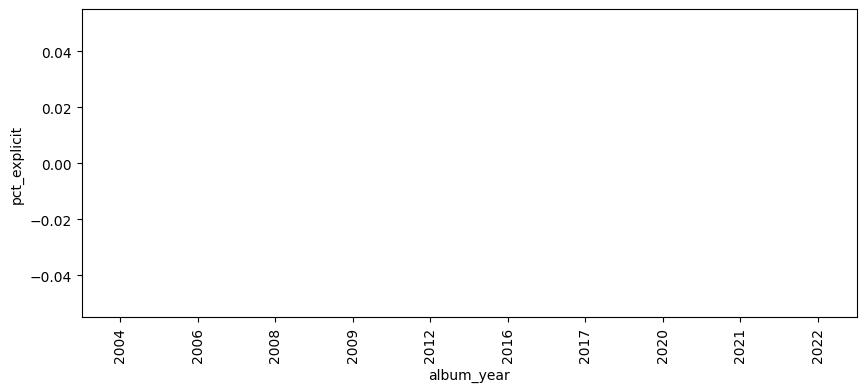

In [0]:
# explicit % per album

plt.figure(figsize=(10,4))
sns.barplot(data=df_album_summary.sort_values('album_year'), x='album_year', y='pct_explicit')
plt.xticks(rotation=90)

# Sentiment vs album popularity

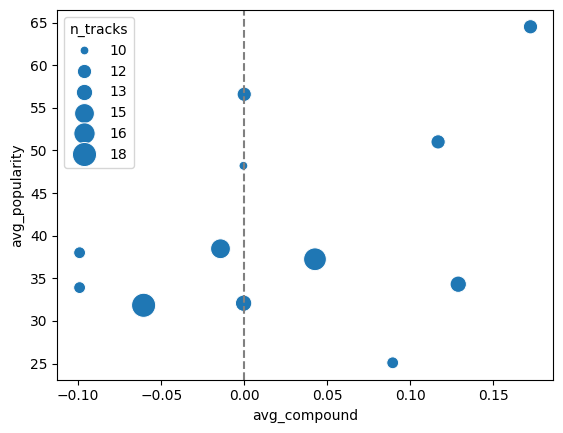

In [0]:
sns.scatterplot(
    data=df_album_summary,
    x='avg_compound',
    y='avg_popularity',
    size='n_tracks',
    sizes=(40, 300)
)
plt.axvline(0, color='gray', linestyle='--')

# Correlation heatmap

<Axes: >

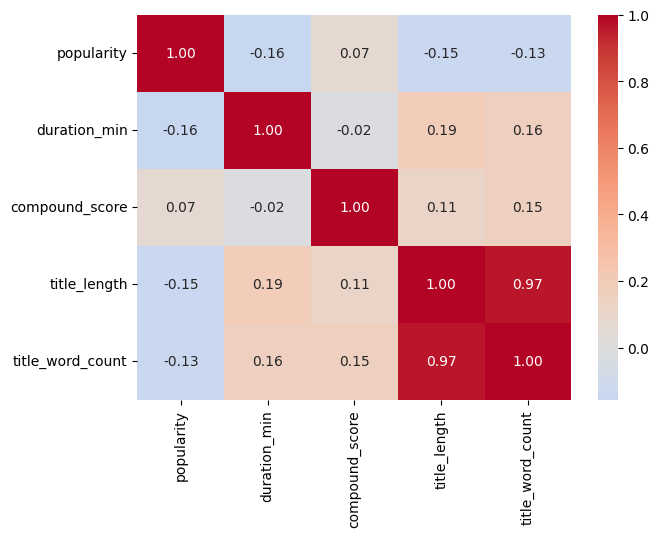

In [0]:
num_cols = ['popularity','duration_min','compound_score','title_length','title_word_count']

plt.figure(figsize=(7,5))
sns.heatmap(df_song[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')

# Sentiment by song summary

- sentiments aggregated by album (the original analysis)
- now merged with the enriched album dataframe

In [0]:
df_sentiments_by_songs = df_song.groupby('album').agg({'compound_score':'mean'}).reset_index().rename({'album':'album_name'}, axis=1)

In [0]:
df_sentiments_by_songs

,album_name,compound_score
0,Battle Born (Deluxe Edition),-0.014300
1,Day & Age (Bonus Tracks),0.116783
2,Don't Waste Your Wishes,0.089427
3,Hot Fuss,0.172433
4,Imploding The Mirage,-0.000490
5,Imploding The Mirage (Deluxe),-0.000377
6,Live From The Royal Albert Hall,0.042618
7,Pressure Machine,-0.099173
8,Pressure Machine (Abridged),-0.099173
9,Pressure Machine (Deluxe),-0.060606


In [0]:
df_summary_by_album = df_sentiments_by_songs.merge(df_all_albumns[['album_name','release_date','album_year']], on='album_name', how='left')

In [0]:
df_summary_by_album

,album_name,compound_score,release_date,album_year
0,Battle Born (Deluxe Edition),-0.014300,2012-09-17,2012
1,Day & Age (Bonus Tracks),0.116783,2008-11-18,2008
2,Don't Waste Your Wishes,0.089427,2016-01-01,2016
3,Hot Fuss,0.172433,2004-01-01,2004
4,Imploding The Mirage,-0.000490,2020-08-21,2020
5,Imploding The Mirage (Deluxe),-0.000377,2021-01-29,2021
6,Live From The Royal Albert Hall,0.042618,2009-11-03,2009
7,Pressure Machine,-0.099173,2021-08-13,2021
8,Pressure Machine (Abridged),-0.099173,2021-08-12,2021
9,Pressure Machine (Deluxe),-0.060606,2022-03-25,2022


<Axes: xlabel='album_year'>

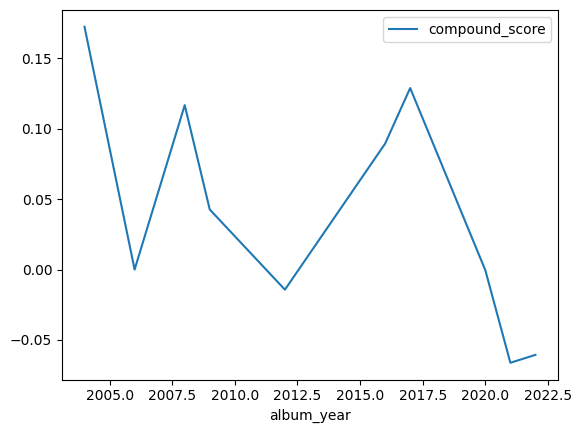

In [0]:
# lineplot

df_summary_by_album.groupby('album_year').agg({'compound_score':'mean'}).plot()

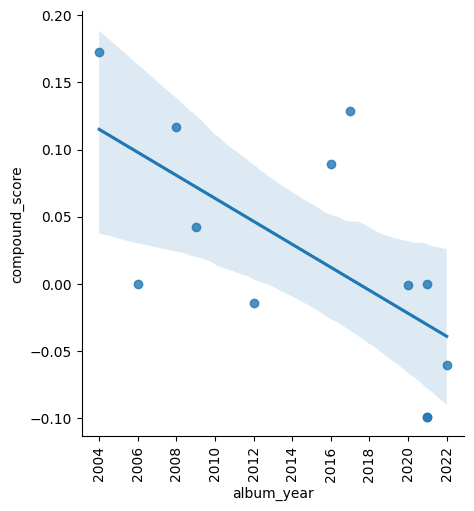

In [0]:
# relational plot

g = sns.lmplot(
    data=df_summary_by_album,
    x="album_year",
    y="compound_score",
)

g.ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.ax.tick_params(axis='x', rotation=90)

# Word cloud

In [0]:
os.makedirs('wordclouds', exist_ok=True)

In [0]:
def generate_wordcloud(artist_name):

    resultados_artista = sp.search(q=artist_name, type="artist", limit=1)

    if resultados_artista["artists"]["items"]:
        id_artista = resultados_artista["artists"]["items"][0]["id"]

        albums = sp.artist_albums(id_artista, album_type="album")

        titulos_canciones = []
        for album in albums["items"]:
            tracks = sp.album_tracks(album["id"])
            titulos_canciones.extend([track["name"] for track in tracks["items"]])

        stop_words = set(stopwords.words("english"))

        titulos_procesados = [" ".join([word.lower() for word in titulo.split() if word.lower() not in stop_words])
                              for titulo in titulos_canciones]

        # tf-idf algorithm

        vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50)
        X = vectorizer.fit_transform(titulos_procesados)

        palabras_importantes = vectorizer.get_feature_names_out()

        valores_importancia = X.sum(axis=0).tolist()[0]
        diccionario_palabras = dict(zip(palabras_importantes, valores_importancia))

        # word cloud

        plt.figure(figsize=(10, 6))
        nube_palabras = WordCloud(width=800, height=400, background_color="white", colormap="coolwarm")
        nube_palabras.generate_from_frequencies(diccionario_palabras)
        plt.imshow(nube_palabras, interpolation="bilinear")
        plt.axis("off")
        plt.savefig(f"./wordclouds/wordcloud_{artist_name}.png")
        plt.close()

    else:
        print("No se encontró al artista.")

In [0]:
generate_wordcloud("The killers")

In [0]:
generate_wordcloud("taylor swift")

In [0]:
generate_wordcloud("linkin park")

# Word frequency comparison

Alternativa cuantitativa al wordcloud: top palabras y bigramas como barras.

In [0]:
def get_top_terms(artist_name, top_n=15, ngram=(1,1)):

    res = sp.search(q=artist_name, type='artist', limit=1)
    aid = res['artists']['items'][0]['id']
    albums = sp.artist_albums(aid, album_type='album')

    titles = []
    for album in albums['items']:
        tracks = sp.album_tracks(album['id'])
        titles.extend([t['name'] for t in tracks['items']])

    stop_words = set(stopwords.words('english'))
    cleaned = [' '.join(w.lower() for w in t.split() if w.lower() not in stop_words and w.isalpha()) for t in titles]

    vec = TfidfVectorizer(ngram_range=ngram, max_features=top_n)
    X = vec.fit_transform(cleaned)

    scores = X.sum(axis=0).tolist()[0]
    return pd.DataFrame({'term': vec.get_feature_names_out(), 'score': scores}).sort_values('score', ascending=False)

<Axes: xlabel='score', ylabel='term'>

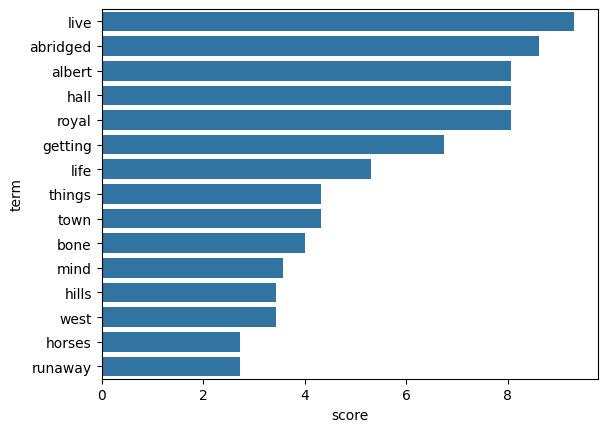

In [0]:
# unigrams for The Killers

df_terms = get_top_terms('The killers', top_n=15)
sns.barplot(data=df_terms, x='score', y='term')

<Axes: xlabel='score', ylabel='term'>

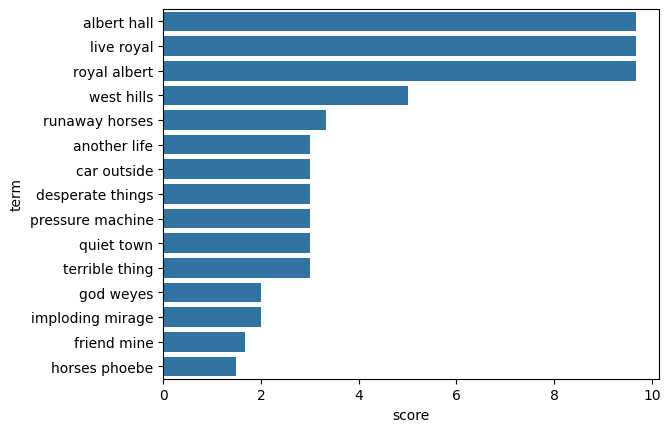

In [0]:
# bigrams for The Killers

df_bigrams = get_top_terms('The killers', top_n=15, ngram=(2,2))
sns.barplot(data=df_bigrams, x='score', y='term')

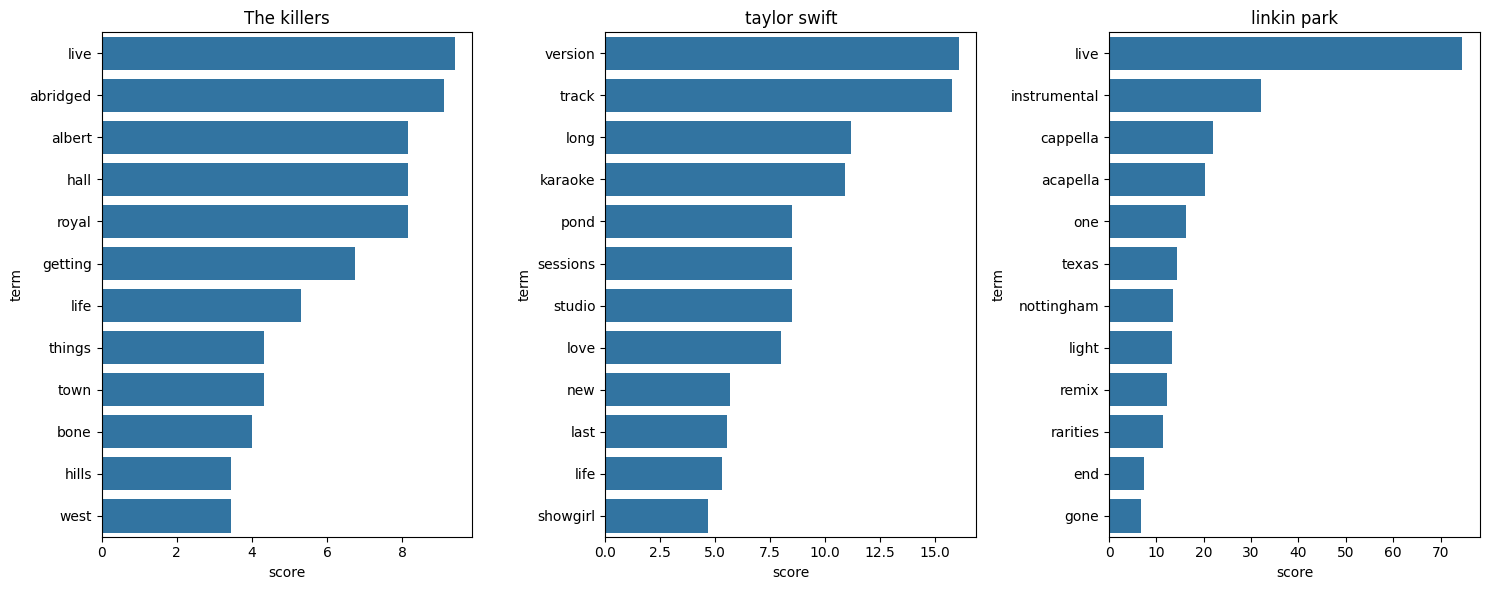

In [0]:
# side by side comparison

artists = ['The killers', 'taylor swift', 'linkin park']

fig, axes = plt.subplots(1, len(artists), figsize=(15, 6), sharex=False)

for ax, a in zip(axes, artists):
    df_t = get_top_terms(a, top_n=12)
    sns.barplot(data=df_t, x='score', y='term', ax=ax)
    ax.set_title(a)

plt.tight_layout()